# 001 Friedel Pairs Labeling - Test

written by Jean-Baptiste Jacob

Last updated: 18/02/2026

Find Friedel pairs in a single s3DXRd dataset. If you need to process a list of datasets, use this notebook to test which parameters work the best for the search, before running the batch process (001_Friedel_Pairs_batch)

### load packages

In [ ]:
import sys

# python environment stuff
IMAGED11_PATH = '/home/esrf/jean1994b/ImageD11_jbjacob'  # None means do not use git, otherwise enter the name of the folder to use for the git checkout "ImageD11" or "ImageD11_version_xx", etc
CHECKOUT_PATH = 'ImageD11'  # the name of the git checkout folder within path. None means guess

if IMAGED11_PATH is not None:
    if '/data/id11/nanoscope' not in sys.path:
        sys.path.append('/data/id11/nanoscope')
    import install_ImageD11_from_git
    PYTHONPATH = install_ImageD11_from_git.setup_ImageD11_from_git(IMAGED11_PATH,CHECKOUT_PATH)
else:
    import site
    PYTHONPATH = site.getsitepackages()[0]
    print(PYTHONPATH)

In [1]:
# General modules
import os
import h5py
import matplotlib.pyplot as pl
import numpy as np

# ImageD11: https://github.com/FABLE-3DXRD/ImageD11
import ImageD11.sinograms.dataset
ImageD11.sparseframe, ImageD11.blobcorrector, ImageD11.columnfile

# pf_3dxrd: Friedel Pair scanning 3DXRD module
# Available at: https://github.com/jbjacob94/pf_3dxrd
# Not yet installable with pip; copy the files into your working folder. Do not forget to add the folder in your sys.path if it is not the case already: sys.path.append('my_path')
from pf3dxrd.pf3dxrd import utils, friedel_pairs, crystal_structure

# Jupyter settings
%matplotlib ipympl
%load_ext autoreload
%autoreload 2

### Load data

In [2]:
def load_data(dsname, parfile, input_format = 'peaktable', return_2D_peaks=False):
    """ 
    load data from peakfile or peaktable 
    
    Args:
    ----------
    dsname (str) : dataset name
    parfile (str): parameter file name
    input_format (str) : either 'peaktable' or 'peakfile'. Control whether data is loaded from an ImageD11 peak table or from a simple peakfile 
    return_2D_peaks (bool): returns 2D peaks instead of 3D peaks (merged in omega) are returned. Only relevant for data loaded from a peak table
                            default is False
    
    Returns:
    cf : ImageD11 columnfile
    ds : ImageD11 dataset
    """
    ####################################
    assert input_format in ['peakfile', 'peaktable'], 'input_format must be either "peakfile" or "peaktable" '
    
    # paths
    ####################################
    if input_format == 'peaktable':
        pksfile = os.path.join(data_dir, dsname+'_peaks_table.h5')
        dsfile  = pksfile.replace('peaks_table','dataset')
    else:
        pksfile = os.path.join(data_dir, dsname+'_pk2d.h5') 
        dsfile  = pksfile.replace('pk2d','dataset')
   
    
    # load ds file and peaks dictionary
    ####################################
    ds = ImageD11.sinograms.dataset.load(dsfile)

    print(f'Loading data for dataset {ds.dsname}: \n==============================')    
    items = 'n_ystep,n_ostep,ymin,ymax,ystep,omin,omax,ostep'.split(',')
    vals  = [ds.shape[0], ds.shape[1], ds.ymin, ds.ymax, ds.ystep, ds.omin, ds.omax, ds.ostep]
    for i,j in zip(items, vals):
        print(f'{i}: {j:.1f}')
        
    print('==============================')
        
    if input_format == 'peakfile':
        print('loading peakfile...')
        pks = ImageD11.columnfile.columnfile(pksfile)
        pkd = {t:pks.getcolumn(t) for t in pks.titles}
         
    else:
        print('loading peaks from peak table...')
        pkst = ImageD11.sinograms.properties.pks_table.load(pksfile)
        
        print('merging peaks...')
        if return_2D_peaks:      
            pkd = pkst.pk2d( ds.omega, ds.dty )         # for 2D peaks
        else:
            pkd = pkst.pk2dmerge( ds.omega, ds.dty )    # for 4D peaks
            
    cf = ImageD11.columnfile.colfile_from_dict(pkd)
    print(f'loaded peakfile: nrows = {cf.nrows}')
    utils.get_colf_size(cf)
    
    return cf, ds


In [16]:
pksfile = os.path.join(data_dir, dsname+'_peaks_table.h5')
os.path.basename(pksfile), ds.dsname

('C18A_01_z180_peaks_table.h5', 'C18A_01_z180')

In [3]:
# define paths
data_dir = '/home/esrf/jean1994b/test_datasets/SI3/'
data_dir = '/home/esrf/jean1994b/test_datasets/C18A_01_z180/'

dsname = 'SI3_DT360Z5480'
dsname = 'C18A_01_z180'
parfile= data_dir+'SI3.par'
parfile = data_dir+'C18A_01.par'

splinefile = data_dir+'/frelon21_mar16.spline'

# load data
cf, ds = load_data(dsname, parfile, input_format='peaktable', return_2D_peaks=True)

Loading data for dataset C18A_01_z180: 
n_ystep: 109.0
n_ostep: 7220.0
ymin: -405.0
ymax: 405.0
ystep: 7.5
omin: 0.0
omax: 360.0
ostep: 0.0
loading peaks from peak table...
merging peaks...
loaded peakfile: nrows = 81805950
Total size =  624.13 MB


### Distortion correction

cf contains raw data columns f_raw, s_raw with raw peak coordinates. These coordinates need to be corrected for detector distortion. Different methods exist depending on the detector used for data acquisition. For the eiger detector of ID11 (nanofocus station), pre-computed distorsion images dxfile, dyfiles are provided, which allow fast distortion correction. For the frelon detector (3DXRD station), a splinefile is provided, from which a pixel lookup table is made, which gives the dx,dy correction for each pixel. 

In [4]:
def correct_distortion_eiger( cf, parfile,
              dxfile="/data/id11/nanoscope/Eiger/spatial_20210415_JW/e2dx.edf",
              dyfile="/data/id11/nanoscope/Eiger/spatial_20210415_JW/e2dy.edf"):
    
    """ 
    FOR EIGER DATA. Apply detector distortion correction for eiger data, using pre-computed disortion files. 
    Adds on the geometric computations (tth, eta, gvector, etc.)
    
    Args: 
    ---------
    cf : ImageD11 columnfile
    parfile (str) : parameter file
    dxfile, dyfile : detector distortion. Default files are valid for the eiger detector on the nanofocus station at ID11 
    """
    
    spat = ImageD11.blobcorrector.eiger_spatial( dxfile = dxfile, dyfile = dyfile )
    cf = ImageD11.columnfile.colfile_from_dict( spat( {t:cf.getcolumn(t) for t in cf.titles} ) )
    cf.parameters.loadparameters(parfile)
    cf.updateGeometry()
    return cf


def correct_distortion_frelon( cf, parfile, splinefile):
    """ 
    FOR FRELON DATA. Apply detector distortion correction using a pixel look up table computed from a splinefile. 
    Adds on the geometric computations (tth, eta, gvector, etc.)
    
    Args: 
    ---------
    cf : ImageD11 columnfile
    parfile (str) : parameter file
    splinefile    : detector distortion splinefile
    detector_dim  : (X,Y) detector dimensions  
    """
    
    spat = ImageD11.blobcorrector.correctorclass(splinefile)
    
    # make pixel_lut  + substract xy grid coordinate (i,j) to keep only dx and dy arrays.
    spat.make_pixel_lut(spat.dim)
    i, j = np.mgrid[ 0:spat.dim[0], 0:spat.dim[1] ]
    dx = spat.pixel_lut[0] - i
    dy = spat.pixel_lut[1] - j
    
    # get integer pixel index (si,fi) of each peak
    si = np.round(cf['s_raw']).astype(int)
    fi = np.round(cf['f_raw']).astype(int)
    
    # apply dx dy correction on s_raw / f_raw
    sc = (dx[ si, fi ] + cf.s_raw).astype(np.float32)
    fc = (dy[ si, fi ] + cf.f_raw).astype(np.float32)
    
    # add corrected arrays as new columns
    cf.addcolumn(sc, 'sc')
    cf.addcolumn(fc, 'fc')
    
    # load parameters and update geometry
    cf.parameters.loadparameters(parfile)
    cf.updateGeometry()
    
    return cf

In [5]:
# detector correction distorsion with frelon data
#cf = correct_distortion_frelon( cf, parfile, splinefile)

# detector correction distorsion with eiger data
cf = correct_distortion_eiger(cf, parfile)

### Pre-processing
clean up a bit the peakfile to remove weak peaks before looking for Friedel pairs

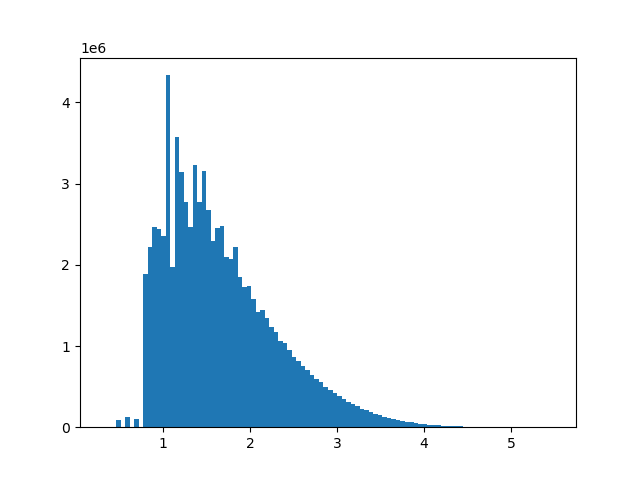

In [6]:
# look at distribution of peak intensity + nb of pixels
pl.figure()
pl.hist(np.log10(cf.sum_intensity),100);

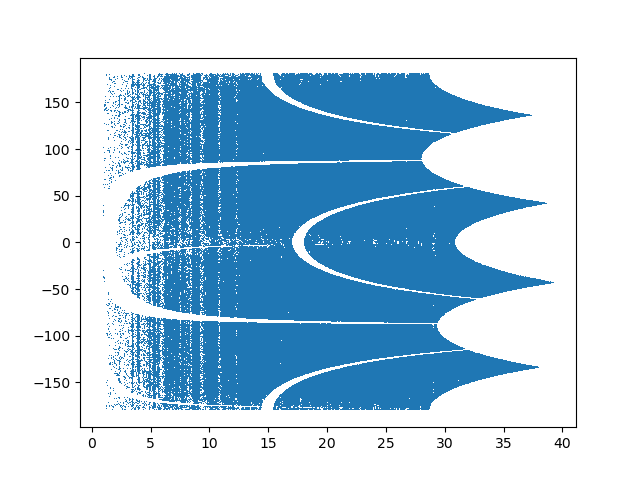

In [7]:
pl.figure()
pl.plot(cf.tth[::10], cf.eta[::10],',')

In [8]:
# filter data
print(cf.nrows)
cf.filter(cf.sum_intensity>10)
cf.filter(cf.number_of_pixels>3)   # column title might be 'Number_of_pixels' depending on how data have been pre-processed
cf.filter(cf.tth < 13.5)

cf.nrows

81805950


AttributeError: 'newcolumnfile' object has no attribute 'number_of_pixels'

Friedel pairs match is found between peaks from symmetric scans (+dty;-dty) acquired at equal distance from the rotation center. Form pairs of dty scans and check data is ok

In [ ]:
# form dty pairs: pairs of (dty,-dty) scans which should contain symmetric information
friedel_pairs.form_y_pairs(cf, ds, disp=True)

dty pairs should have roughly the same number of peaks assigned. If not, the sample is certainly not very well aligned on the rotation center (not a big deal), or maybe it has moved during scanning (more problematic)

In [ ]:
# check symmetry of intensity and number of pixels 
friedel_pairs.check_y_symmetry(cf, ds, saveplot=False)

### Friedel pair labeling

Find Fridel pairs on one pair of scans, to see how it looks. The two paremeters dist_max and dist_step control the distance threshold applied for nearest-neighbor search. At each iteration, the distance threshold is increased of dist_step, until the value dist_max is reached. This distance is expressed in a 4D space formed using two-theta, eta, omega, intensity, each rescaled and normalized to a value between zero and 1. fp_dist is the total euclidian distance between two peaks in a pair in the 4D search space. If doplot is True, histograms of the 4D Euclidian distance + distance along each dimension (expressed in meaningful angle or value) are plotted

198376 pairs kept out of  607435  possible matches
148938 pairs kept out of  409059  possible matches
68035 pairs kept out of  260121  possible matches
32960 pairs kept out of  192086  possible matches
18073 pairs kept out of  159126  possible matches
11520 pairs kept out of  141053  possible matches
8670 pairs kept out of  129533  possible matches
Friedel pair matching Completed.
N pairs = 486572 out of 607435 possible candidates
Fraction of peaks matched = 0.80
Fraction of intensity matched = 0.89
dstep_max = 0.700


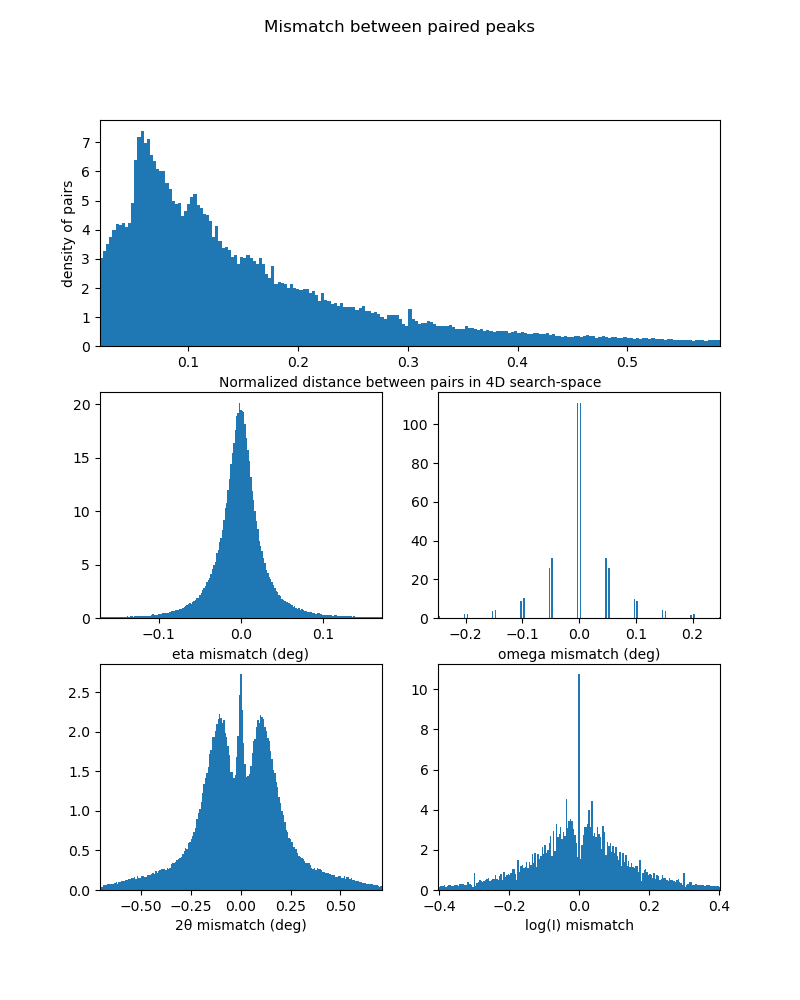

In [11]:
# select peaks from a pair
c1, c2 = friedel_pairs.select_y_pair(cf, ds, pair_id = 0)

# friedel pair search. let's try first with these values
cp = friedel_pairs.label_friedel_pairs(c1,c2,
                                  dist_max = .7,
                                  dist_step = 0.1,
                                  mtth = 2,
                                  mI = 1,
                                  verbose=True,
                                  doplot=True)

Try to adjust dist_threshold and dist_max until Fridel pair matching looks good. Once you are satisfied with your parameters, you can run Friedel pair search on the whole dataset. Two options:
- use the function find_all_pairs below. It iterates label_friedel_pairs on all ypairs in the dataset and then merges all outputs in a single peakfile.
- run pair search in batch mode (001b_friedel_pairs_batch.ipynb)

Friedel pair search...


100%|██████████| 55/55 [00:24<00:00,  2.20it/s]


Updating Friedel pair labels


100%|██████████| 54/54 [00:00<00:00, 508.98it/s]


Merging peakfiles...
Friedel pair matching Completed.
N pairs =  1265960
Fraction of peaks matched = 0.80
Fraction of total intensity matched = 0.95


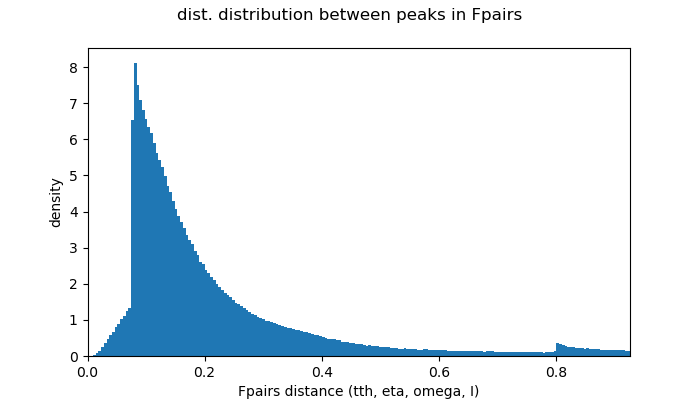

In [58]:
# option 1: no parallellization
out = friedel_pairs.find_all_pairs(cf,
                                   ds,
                                   dist_max=1.,
                                   dist_step=0.1,
                                   mI=1/5,
                                   mtth=1/5)


cf_paired, fp_labels, stats = friedel_pairs.merge_outputs(out, cf, doplot=True)

In [59]:
# Plot the distribution of mismatch between Friedel pair along each dimension: eta, omega, tth, sumI. split between low fp_dist and large fp_dist subsets

/cvmfs/hpc.esrf.fr/software/packages/linux/x86_64/jupyter-slurm/2025.04.5/envs/jupyter-slurm/lib/python3.12/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


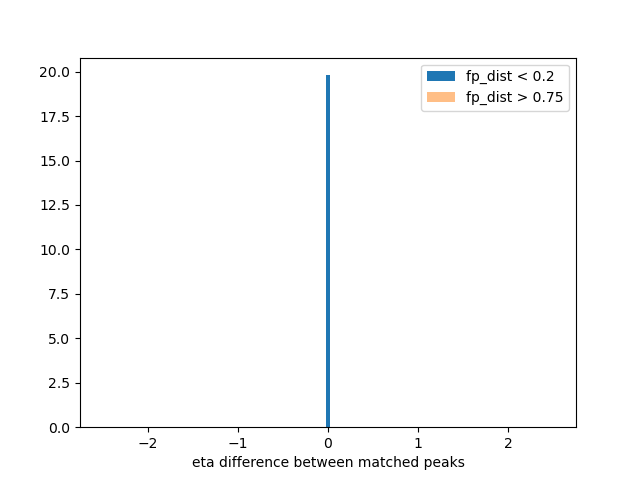

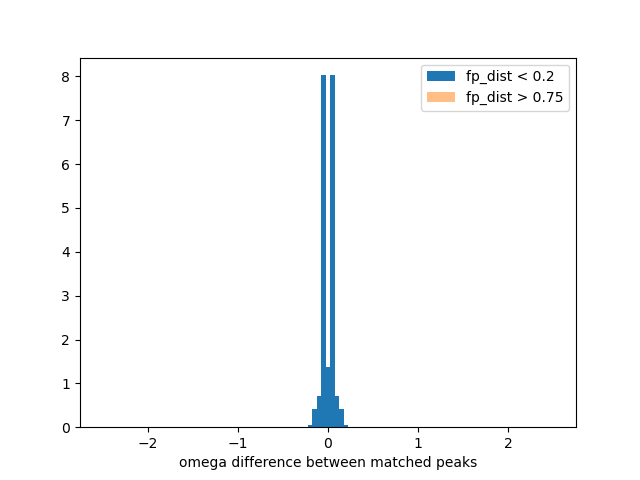

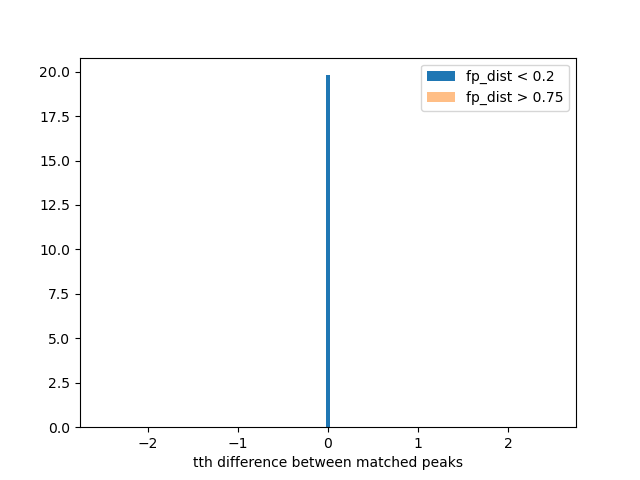

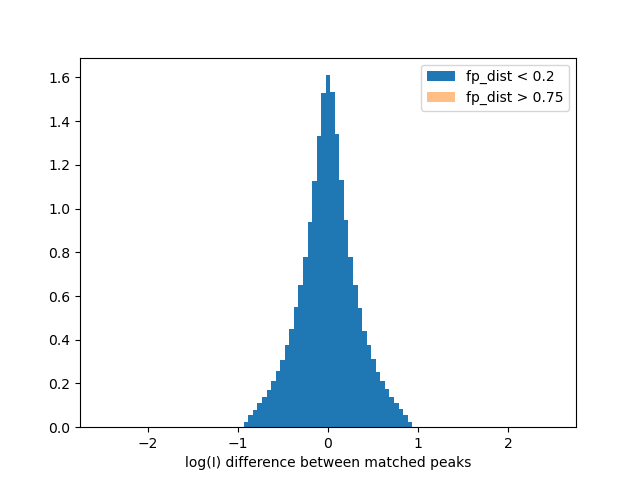

In [66]:
c1, c2 = friedel_pairs.split_fpairs(cf_paired)
dlow, dhigh = 0.2, 0.75
m = c1.fp_dist < dlow
m2 = c1.fp_dist > dhigh


pl.figure()
pl.hist(c1.eta[m]%360 - (180-c2.eta[m])%360,bins=np.linspace(-2.5,2.5,100), density=True, label=f'fp_dist < {dlow}');
pl.hist(c1.eta[m2]%360 - (180-c2.eta[m2])%360,bins=np.linspace(-2.5,2.5,100), alpha=.5, density=True, label = f'fp_dist > {dhigh}');
pl.xlabel('eta difference between matched peaks')
pl.legend()


pl.figure()
pl.hist(c1.omega[m]%360 - (180+c2.omega[m])%360,bins=np.linspace(-2.5,2.5,100), density=True, label=f'fp_dist < {dlow}');
pl.hist(c1.omega[m2]%360 - (180+c2.omega[m2])%360,bins=np.linspace(-2.5,2.5,100), alpha=.5, density=True, label = f'fp_dist > {dhigh}');
pl.xlabel('omega difference between matched peaks')
pl.legend()


pl.figure()
pl.hist(c1.tth[m] - (c2.tth[m]),bins=np.linspace(-2.5,2.5,100), density=True, label=f'fp_dist < {dlow}');
pl.hist(c1.tth[m2] - (c2.tth[m2]),bins=np.linspace(-2.5,2.5,100), alpha=.5, density=True, label = f'fp_dist > {dhigh}');
pl.xlabel('tth difference between matched peaks')
pl.legend()


pl.figure()
pl.hist(np.log10(c1.sum_intensity[m]) - np.log10(c2.sum_intensity[m]),bins=np.linspace(-2.5,2.5,100), density=True, label=f'fp_dist < {dlow}');
pl.hist(np.log10(c1.sum_intensity[m2]) - np.log10(c2.sum_intensity[m2]),bins=np.linspace(-2.5,2.5,100), alpha=.5, density=True, label = f'fp_dist > {dhigh}');
pl.xlabel('log(I) difference between matched peaks')
pl.legend()


In [61]:
# filter out peaks with fp_dist too large (dodgy)
cf_paired.filter(cf_paired.fp_dist < 0.75)

### Geometry correction
correct 2θ angle and relocates peaks in sample space


In [62]:
# use measured tth from both peak in each pair to find the offset-corrected two-theta angle + relocate peak sources in the sample 
friedel_pairs.update_geometry_fpairs(cf_paired, ds, relocate_fpairs=True)
cf_paired.titles

copied an array: size=2426812, elsize=4
copied an array: size=2426812, elsize=4
copied an array: size=2426812, elsize=4
copied an array: size=2426812, elsize=4


['omega',
 's_raw',
 'f_raw',
 'sum_intensity',
 'dty',
 'number_of_pixels',
 'sc',
 'fc',
 'xl',
 'yl',
 'zl',
 'tth',
 'eta',
 'ds',
 'gx',
 'gy',
 'gz',
 'fp_id',
 'fp_dist',
 'xs',
 'ys',
 'r_dist']

Text(0, 0.5, 'probability density')

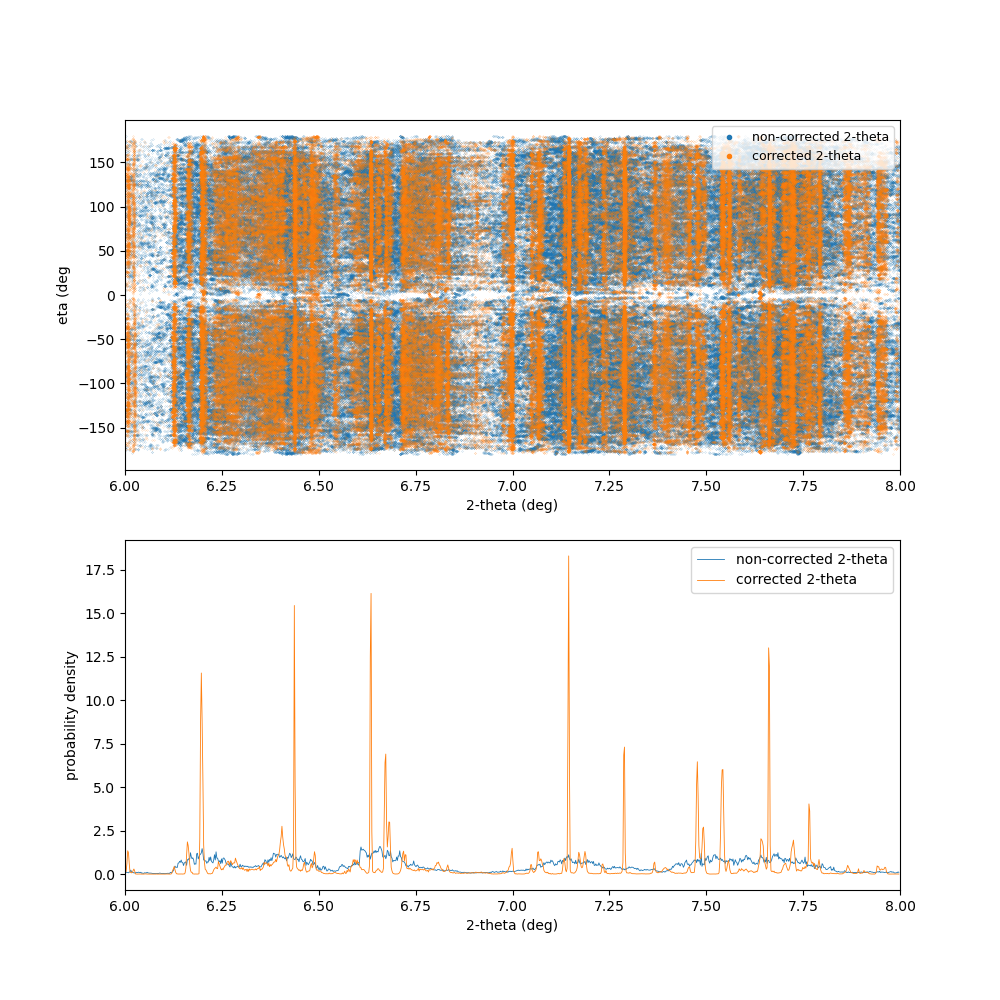

In [63]:
# plot 2-theta vs. eta for corrected vs non-corrected tth on a subset of the two-theta range
tthmin, tthmax = 6,8

fig = pl.figure(figsize=(10,10))
fig.add_subplot(211)
pl.plot(cf.tth, cf.eta, '.', ms = .2, label='non-corrected 2-theta') 
pl.plot(cf_paired.tth, cf_paired.eta, '.', ms=.2, label='corrected 2-theta')
pl.xlabel('2-theta (deg)')
pl.ylabel('eta (deg')
pl.xlim(tthmin, tthmax)
pl.legend(markerscale=30, loc='upper right', fontsize=9) 

# 2-theta histogram for corrected vs non-corrected peaks
fig.add_subplot(212)
h,b,_ = utils.compute_tth_histogram(cf, tthmin=tthmin, tthmax = tthmax, tthstep = 0.002,
                                    uself = True, doplot=False, density=True)
hc,bc,_ = utils.compute_tth_histogram(cf_paired, tthmin=tthmin, tthmax = tthmax, tthstep = 0.002,
                                      uself = True, doplot=False, density=True)

pl.plot(b,h,'-', lw=.6, label='non-corrected 2-theta')
pl.plot(bc,hc,'-',lw=.6, label='corrected 2-theta')
pl.legend()
pl.xlim(tthmin, tthmax)
pl.xlabel('2-theta (deg)')
pl.ylabel('probability density')

#### Comparison with computed hkl rings

compare hkl ring positions with those computed from a list of known crystal structures

CS: quartz, phase_id: 0, spg: P3221, spg_no: 154, lattice: [  4.91325   4.91325   5.41206  90.       90.      120.     ]
CS: orthoclase, phase_id: 1, spg: C1-11, spg_no: 12, lattice: [  8.589  13.013   7.197  90.    116.02   90.   ]
CS: oligoclase, phase_id: 2, spg: C-1, spg_no: 2, lattice: [  8.154  12.823   7.139  94.06  116.5    88.59 ]
CS: biotite, phase_id: 3, spg: C12/m1, spg_no: 12, lattice: [  5.355   9.251  10.246  90.    100.15   90.   ]
CS: magnetite, phase_id: 4, spg: Fd3m, spg_no: 227, lattice: [ 8.3965  8.3965  8.3965 90.     90.     90.    ]
Scatter(quartz with 2 atomic positions, 6 symmetries)
       Type: x-ray
     Energy: 43.57356018082551 keV
 Wavelength: 0.28454050670689945 A
 ---Settings---
      Powder units: tth
    Isotropic ADPs: True
  Specular Direction (reflection): ( 0, 0, 1)
Parallel Direction (transmission): ( 0, 0, 1)
      theta offset: 0.0
         min theta: -180.0
         max theta: 180.0
      min twotheta: 2
      max twotheta: 13.499713292118116

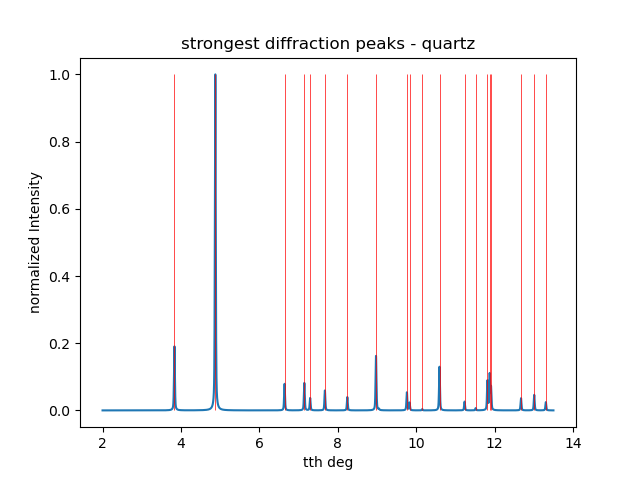

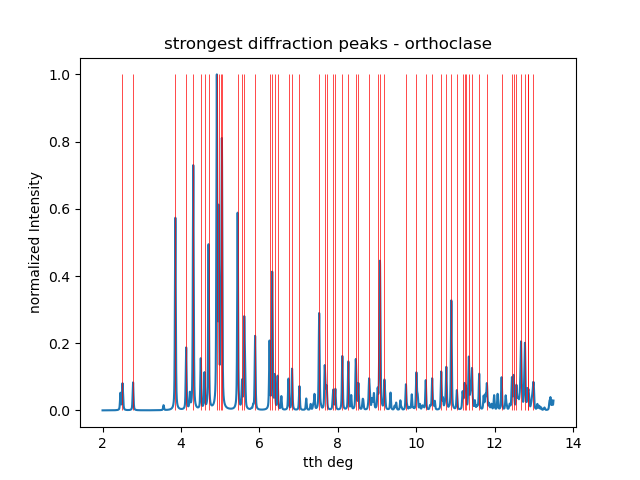

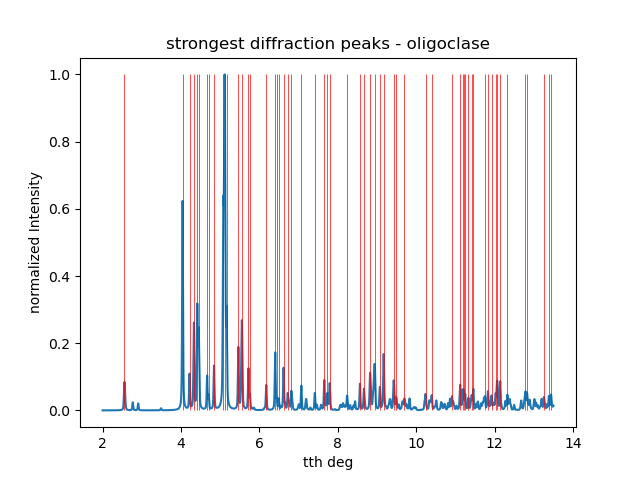

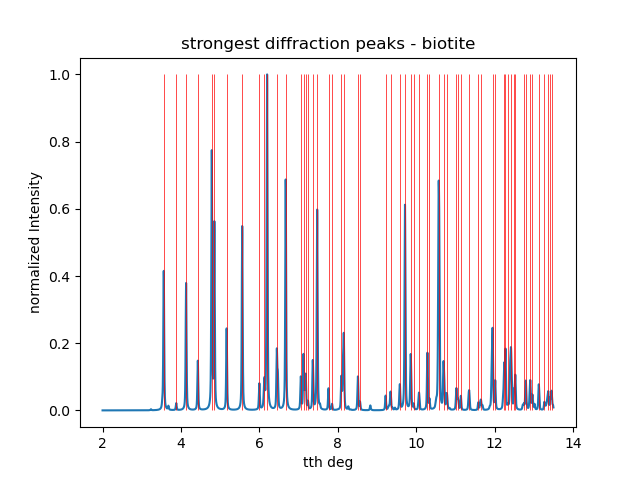

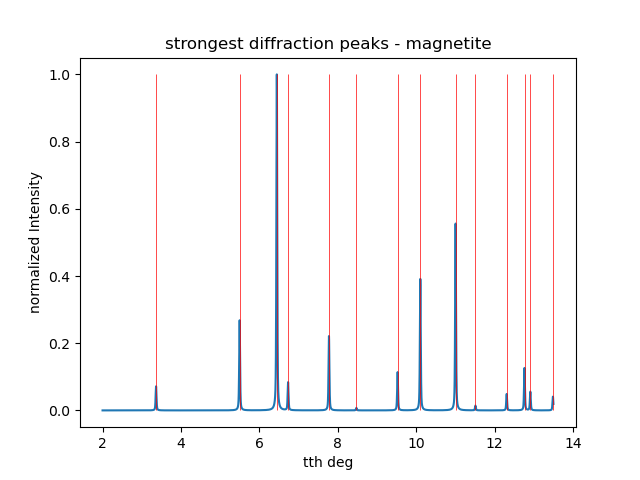

In [67]:
# define a phase dictionary containign crystal structure information from CIF files (in the /cif folder). Phase names have to match cif file names (e.g. quartz.cif) 
phase_names = ['quartz', 'orthoclase', 'oligoclase', 'biotite', 'magnetite']  # list of phases to consider. depends on dataset: ['quartz'] alone, ['quartz','garnet'], etc.
#phase_names = ['quartz']
phase_dict = {}

# load crystal structures from cif files. They should all be in the /cif folder
for i,p in enumerate(phase_names):
    cs = crystal_structure.load_CS_from_cif(cif_path = f'cif/{p}.cif', name=p, pid=i)
    print(cs)
    phase_dict[p] = cs
    
    
wl = cf.parameters.get('wavelength')

# compute theoretical 2θ rings: compute a simulated powder spectrum, and then we run a peaksearch on this spectrum to find the N-strongest peaks.
# This allows to retain only the most significant peaks, and not care about all the numerous, very low intensity peaks which theoretically exist but 
#are practically barely visible.

for cs in phase_dict.values():
    cs.compute_powder_spec(wl, min_tth=2, max_tth=cf_paired.tth.max(), doplot=False)
    cs.find_strongest_peaks(Imin=0.001, prominence=0.001, Nmax=60, doplot=True)

Now we can replot the data with these theoretical peaks

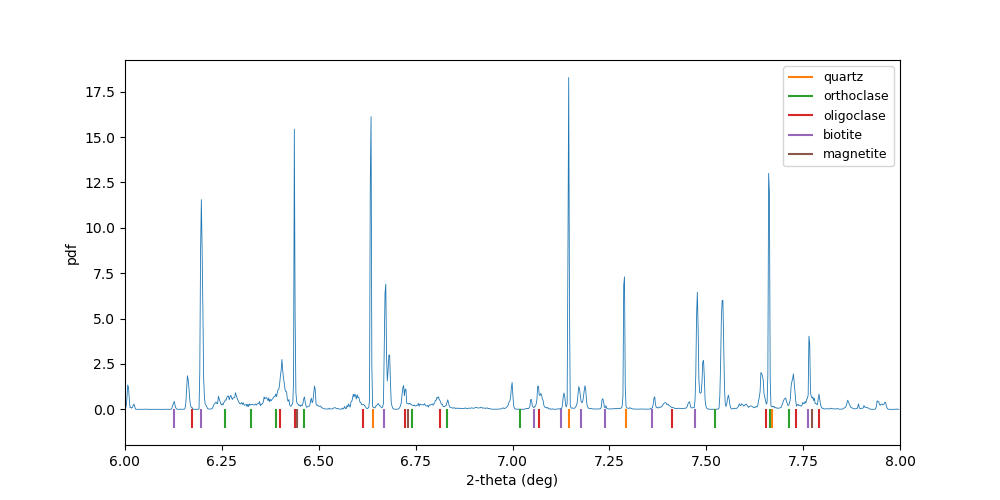

In [65]:
# replot 2θ vs η and add computed hkl ring positions for each phase
colors = pl.matplotlib.cm.tab10.colors

pl.figure(figsize=(10,5))
pl.plot(bc,hc, '-', lw=.6)

for p,cs in phase_dict.items():
    pl.vlines(cs.strong_peaks[0], -1,0, colors = colors[cs.phase_id+1], label=p)
pl.xlabel('2-theta (deg)')
pl.ylabel('pdf')
pl.xlim(tthmin, tthmax)

pl.legend(loc='upper right', fontsize=9) 

### Sample reconstruction
Reconstruct an image of the sample by mapping the total intensity of diffraction peaks reprojected in sample space

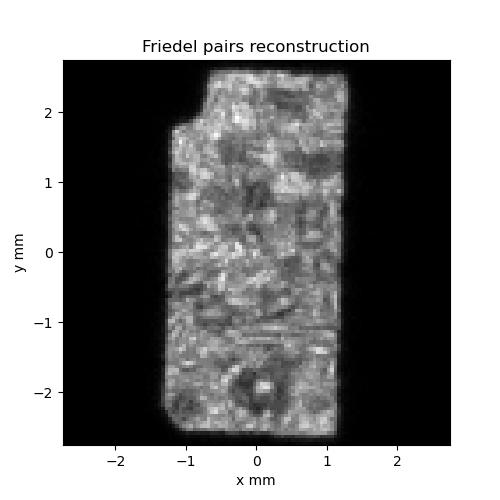

In [27]:
# plot sample reconstruction
kw = {'cmap':'Greys_r'}

utils.friedel_recon(cf_paired,
                    xbins = ds.ybinedges,
                    ybins = ds.ybinedges,
                    doplot=True,
                    mask = None,
                    weight_by_intensity=True,
                    norm = True,
                    **kw );


In [28]:
# filter out peaks outside the ROI, to keep only portions of the map with complete data
cf_paired.filter(cf_paired.r_dist <= ds.ybinedges.max())

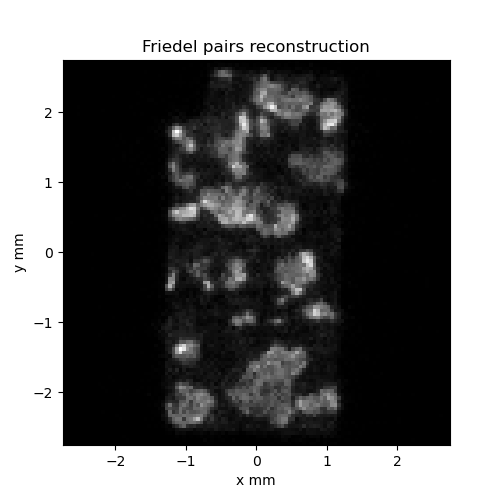

In [68]:
# computere construction using only one phase (e.g. quartz)
mask_qtz = utils.select_tth_rings_fast(cf_paired, phase_dict['quartz'].strong_peaks[0][:10], tth_tol=0.02, tth_max=cf_paired.tth.max())
kw = {'cmap':'Greys_r'}   # keyword arg to pass to plot function

# plot reconstruction for quartz peaks only
utils.friedel_recon(cf_paired,
                    xbins = ds.ybinedges,
                    ybins = ds.ybinedges,
                    doplot=True,
                    mask = mask_qtz,
                    weight_by_intensity=True,
                    norm = True,
                    **kw );

### save peakfile

In [31]:
# save data. The 'minimal' save mode means that only the necessary data columns are kept. All data that can be recomputed from other columns are dropped.
utils.colf_to_hdf(cf_paired, os.path.join(data_dir, dsname+'_pk2d_p.h5'), save_mode='minimal')